In [1]:
%pip install -q wordcloud emoji contractions
%pip install -q -U scikit-learn
%pip install -q -U "transformers>=4.46" "datasets>=2.20" accelerate evaluate
%pip install -q lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 21.7 MB/s eta 0:00:00


In [2]:
import os, re, json, random, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print("Colab ortamı:", IN_COLAB)
try:
    import torch
    print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "yok (CPU)")
except ImportError:
    print("torch yüklü değil")

Colab ortamı: True
GPU: Tesla T4


In [4]:
DATA_PATH = "tweet_data.csv"

if not os.path.exists(DATA_PATH):
    if IN_COLAB:
        # Seçenek A — dosyayı elle yükle (en pratik)
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    else:
        raise FileNotFoundError(f"{DATA_PATH} bulunamadı. Dosyayı defterle aynı klasöre koyun.")

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

Saving tweet_data.csv to tweet_data.csv
(18727, 3)


,textID,tweet_text,sentiment
0,1956967666,Layin n bed with a headache ughhhh...waitin on your call...,negative
1,1956967696,Funeral ceremony...gloomy friday...,negative
2,1956967789,wants to hang out with friends SOON!,positive
3,1956968477,Re-pinging @ghostridah14: why didn't you go to prom? BC my bf didn't like my friends,negative
4,1956968636,Hmmm. http://www.djhero.com/ is down,negative


In [5]:
print("Satır sayısı:", len(df))
print("\nSütunlar / tipler:")
print(df.dtypes)
print("\nEksik değerler:")
print(df.isna().sum())
print("\nTam yinelenen metin sayısı:", df["tweet_text"].duplicated().sum())
print("\nSınıf dağılımı:")
print(df["sentiment"].value_counts())

Satır sayısı: 18727

Sütunlar / tipler:
textID         int64
tweet_text    object
sentiment     object
dtype: object

Eksik değerler:
textID        0
tweet_text    0
sentiment     0
dtype: int64

Tam yinelenen metin sayısı: 112

Sınıf dağılımı:
sentiment
positive    9897
negative    8830
Name: count, dtype: int64


In [6]:
df = df.dropna(subset=["tweet_text", "sentiment"]).copy()
df["tweet_text"] = df["tweet_text"].astype(str).str.strip()
df = df[df["tweet_text"].str.len() > 0]
before = len(df)
df = df.drop_duplicates(subset=["tweet_text"]).reset_index(drop=True)
print(f"{before - len(df)} yinelenen kayıt atıldı. Kalan: {len(df)}")

df["label"] = (df["sentiment"] == "positive").astype(int)
df["label"].value_counts(normalize=True)

112 yinelenen kayıt atıldı. Kalan: 18615


,proportion
label,
1,0.526457
0,0.473543


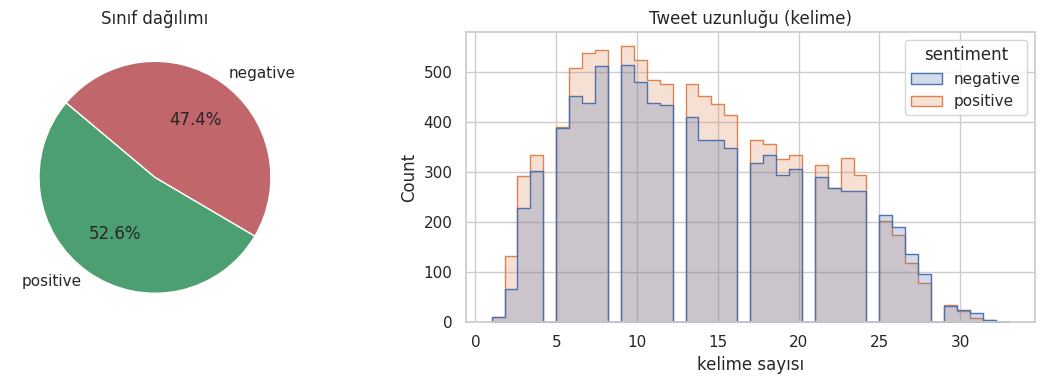

                mean   50%   max
sentiment                       
negative   13.778673  13.0  32.0
positive   13.500306  13.0  33.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["sentiment"].value_counts()
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=140,
            colors=["#4C9F70", "#C1666B"])
axes[0].set_title("Sınıf dağılımı")

df["n_words"] = df["tweet_text"].str.split().str.len()
sns.histplot(data=df, x="n_words", hue="sentiment", bins=40, ax=axes[1], element="step")
axes[1].set_title("Tweet uzunluğu (kelime)")
axes[1].set_xlabel("kelime sayısı")
plt.tight_layout(); plt.show()

print(df.groupby("sentiment")["n_words"].describe()[["mean", "50%", "max"]])

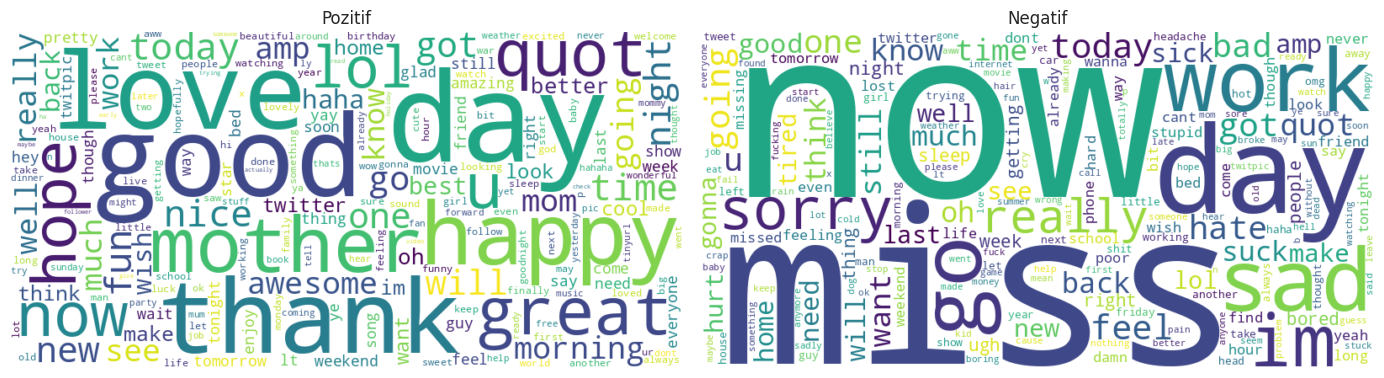

In [8]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lab, title in zip(axes, ["positive", "negative"], ["Pozitif", "Negatif"]):
    txt = " ".join(df.loc[df["sentiment"] == lab, "tweet_text"].str.lower())
    wc = WordCloud(width=800, height=400, background_color="white",
                   collocations=False, random_state=SEED).generate(txt)
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(title)
plt.tight_layout(); plt.show()

In [9]:
def replace_retweet(tweet, default_replace=""):
    return re.sub(r"\bRT\b\s*", default_replace, tweet)

def replace_user(tweet, default_replace=" "):
    return re.sub(r"\B@\w+", default_replace, tweet)

def replace_url(tweet, default_replace=" "):
    return re.sub(r"https?://\S+|www\.\S+", default_replace, tweet)

def replace_hashtag(tweet, default_replace=" "):
    return re.sub(r"#", default_replace, tweet)

def to_lowercase(tweet):
    return tweet.lower()

def char_repetition(tweet):
    return re.sub(r"(.)\1{2,}", r"\1\1", tweet)

def punct_repetition(tweet, default_replace=""):
    return re.sub(r"([\?\.\!])\1+", r"\1", tweet)

In [10]:
try:
    import emoji
    def demojize(tweet):
        return emoji.demojize(tweet, delimiters=(" ", " "))
except ImportError:
    def demojize(tweet):
        return tweet

try:
    import contractions
    def fix_contractions(tweet):
        return contractions.fix(tweet)
except ImportError:
    _CONTRACTIONS = {"n't": " not", "'re": " are", "'s": " is", "'d": " would",
                     "'ll": " will", "'ve": " have", "'m": " am"}
    def fix_contractions(tweet):
        for k, v in _CONTRACTIONS.items():
            tweet = tweet.replace(k, v)
        return tweet

In [11]:
demo = "RT @AIOutsider I looooove this!!! 👍 https://AIOutsider.com #NLP #Fun. I don't hate it."

steps = [("retweet", replace_retweet), ("user", replace_user), ("url", replace_url),
         ("hashtag", replace_hashtag), ("lowercase", to_lowercase),
         ("contractions", fix_contractions), ("punct", punct_repetition),
         ("char rep", char_repetition), ("emoji", demojize)]

t = demo
print(f"{'başlangıç':<14} | {t}")
for name, fn in steps:
    t = fn(t)
    print(f"{name:<14} | {t}")

başlangıç      | RT @AIOutsider I looooove this!!! 👍 https://AIOutsider.com #NLP #Fun. I don't hate it.
retweet        | @AIOutsider I looooove this!!! 👍 https://AIOutsider.com #NLP #Fun. I don't hate it.
user           |   I looooove this!!! 👍 https://AIOutsider.com #NLP #Fun. I don't hate it.
url            |   I looooove this!!! 👍   #NLP #Fun. I don't hate it.
hashtag        |   I looooove this!!! 👍    NLP  Fun. I don't hate it.
lowercase      |   i looooove this!!! 👍    nlp  fun. i don't hate it.
contractions   |   i looooove this!!! 👍    nlp  fun. i do not hate it.
punct          |   i looooove this! 👍    nlp  fun. i do not hate it.
char rep       |   i loove this! 👍  nlp  fun. i do not hate it.
emoji          |   i loove this!  thumbs_up   nlp  fun. i do not hate it.


In [12]:
NEGATIONS = {"not", "no", "nor", "never", "none", "nothing", "cannot",
             "n't", "without", "hardly", "barely"}

try:
    import nltk
    for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
                "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
        try:
            nltk.download(pkg, quiet=True)
        except Exception:
            pass
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords, wordnet
    from nltk.stem import WordNetLemmatizer, SnowballStemmer
    from nltk import pos_tag

    STOP_WORDS = set(stopwords.words("english")) - NEGATIONS
    _lemmatizer = WordNetLemmatizer()
    _stemmer = SnowballStemmer("english")
    NLTK_OK = True
except Exception as e:
    print("NLTK kullanılamıyor, yedek tokenizer devrede:", e)
    STOP_WORDS = {"i","me","my","we","our","you","your","the","a","an","and","or","is",
                  "are","was","were","be","been","to","of","in","on","at","it","this",
                  "that","for","with","as","so","but","if","then","there","here","he",
                  "she","they","them","his","her","do","does","did","have","has","had",
                  "am","by","from","up","out","about","just","too","very","will","would",
                  "should","what","when","where","who","how","all","any","some","than"}
    NLTK_OK = False

def _wordnet_pos(tag):
    return {"J": "a", "V": "v", "N": "n", "R": "r"}.get(tag[0], "n")

def tokenize(tweet, remove_stop=True, min_len=2):
    if NLTK_OK:
        tokens = word_tokenize(tweet)
    else:
        tokens = re.findall(r"[a-z']+", tweet.lower())
    tokens = [t for t in tokens if t not in string.punctuation and t.isalpha()]
    tokens = [t for t in tokens if len(t) >= min_len or t in NEGATIONS]
    if remove_stop:
        tokens = [t for t in tokens if t not in STOP_WORDS or t in NEGATIONS]
    return tokens

def lemmatize_tokens(tokens):
    if not NLTK_OK or not tokens:
        return tokens
    return [_lemmatizer.lemmatize(tok, _wordnet_pos(tag)) for tok, tag in pos_tag(tokens)]

def stem_tokens(tokens):
    return [_stemmer.stem(t) for t in tokens] if NLTK_OK else tokens

In [13]:
def mark_negation(tokens, scope=3):
    out, countdown = [], 0
    for tok in tokens:
        if tok in NEGATIONS:
            out.append(tok); countdown = scope; continue
        out.append(f"NOT_{tok}" if countdown > 0 else tok)
        countdown = max(0, countdown - 1)
    return out

print(mark_negation(["not", "good", "at", "all", "but", "fine"]))

['not', 'NOT_good', 'NOT_at', 'NOT_all', 'but', 'fine']


In [14]:
def clean_text(tweet):
    """Model girdisine hazır, temizlenmiş düz metin (transformer'lar için de bu kullanılır)."""
    tweet = replace_retweet(tweet)
    tweet = replace_user(tweet)
    tweet = replace_url(tweet)
    tweet = replace_hashtag(tweet)
    tweet = demojize(tweet)
    tweet = fix_contractions(tweet)
    tweet = punct_repetition(tweet)
    tweet = char_repetition(tweet)
    return re.sub(r"\s+", " ", tweet).strip()

def process_tweet(tweet, use_lemma=True, negation=True, as_string=True):
    """Klasik modeller için token listesi ya da boşlukla birleştirilmiş string."""
    text = to_lowercase(clean_text(tweet))
    tokens = tokenize(text)
    tokens = lemmatize_tokens(tokens) if use_lemma else stem_tokens(tokens)
    if negation:
        tokens = mark_negation(tokens)
    return " ".join(tokens) if as_string else tokens

complex_tweet = """RT @AIOutsider : he looooook,
THis is a big and complex TWeet!!! 👍 ...
We'd be glad if you couldn't normalize it!
Check https://t.co/7777 and LET ME KNOW!!! #NLP #Fun"""

print("clean_text  ->", clean_text(complex_tweet))
print("process     ->", process_tweet(complex_tweet))

clean_text  -> : he look, THis is a big and complex TWeet! thumbs_up . We would be glad if you could not normalize it! Check and LET ME KNOW! NLP Fun
process     -> look big complex tweet would glad could not NOT_normalize NOT_check NOT_let know nlp fun


In [15]:
%%time
df["clean"]  = df["tweet_text"].map(clean_text)
df["tokens"] = df["tweet_text"].map(process_tweet)
df[["tweet_text", "clean", "tokens", "label"]].sample(5, random_state=SEED)

CPU times: user 21.9 s, sys: 6.11 ms, total: 21.9 s
Wall time: 37.9 s


,tweet_text,clean,tokens,label
15685,"just got to kansas city and excited for a fun weekend with my family, my sis, parker and josh","just got to kansas city and excited for a fun weekend with my family, my sis, parker and josh",get kansas city excite fun weekend family si parker josh,1
409,I cant to sleep and tomorrow i must wake up too early,I cannot to sleep and tomorrow i must wake up too early,not NOT_sleep NOT_tomorrow NOT_must wake early,0
13141,@shrinkingjes WHOO HOO. Congrats on getting under 200lbs,WHOO HOO. Congrats on getting under 200lbs,whoo hoo congrats get,1
8922,upset.. friday night crying!,upset. friday night crying!,upset friday night cry,0
5847,ok so this eye doctor guy is taking forever and i'm sitting in a cold room by myself...what? A jerk!,ok so this eye doctor guy is taking forever and i am sitting in a cold room by myself.what? A jerk!,ok eye doctor guy take forever sit cold room jerk,0


In [16]:
from sklearn.model_selection import train_test_split

X_tmp, X_test, y_tmp, y_test = train_test_split(
    df[["clean", "tokens"]], df["label"], test_size=0.15, stratify=df["label"], random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15, stratify=y_tmp, random_state=SEED)

for name, part in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:<6} n={len(part):>6}  pozitif oranı={part.mean():.3f}")

train  n= 13448  pozitif oranı=0.526
val    n=  2374  pozitif oranı=0.527
test   n=  2793  pozitif oranı=0.526


In [17]:
from collections import defaultdict

def build_freqs(token_strings, labels):
    freqs = defaultdict(int)
    for text, lab in zip(token_strings, labels):
        for word in text.split():
            freqs[(word, lab)] += 1
    return freqs

def tweet_to_freq(text, freqs):
    x = np.zeros(3)
    x[0] = 1.0  # bias
    for word in text.split():
        x[1] += freqs.get((word, 1), 0)
        x[2] += freqs.get((word, 0), 0)
    return x

freqs = build_freqs(X_train["tokens"], y_train)
print("Sözlük büyüklüğü (kelime, sınıf) çifti:", len(freqs))
print("'love' pozitifte:", freqs.get(("love", 1)), "| negatifte:", freqs.get(("love", 0)))

Sözlük büyüklüğü (kelime, sınıf) çifti: 17919
'love' pozitifte: 844 | negatifte: 35


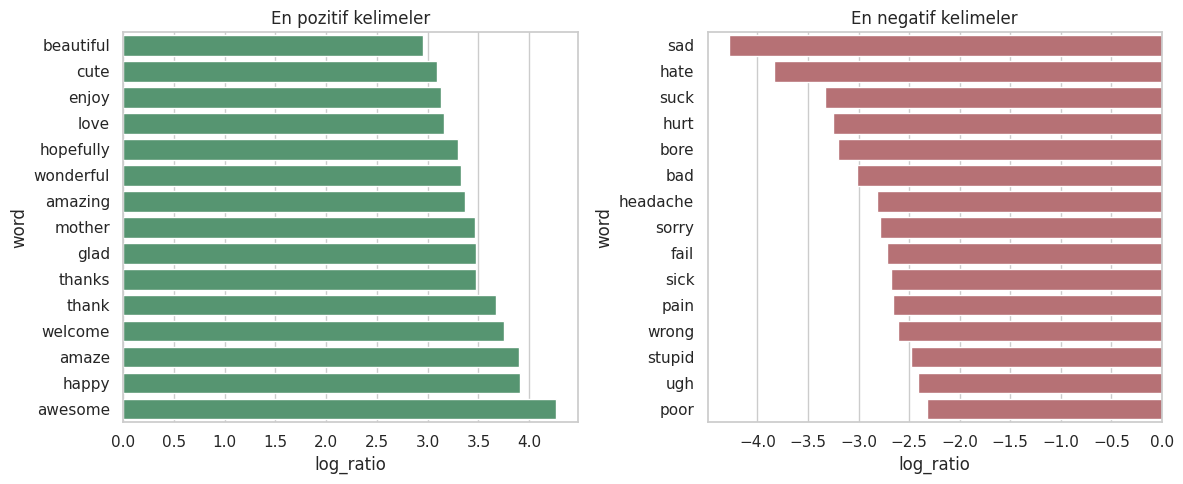

In [18]:
from collections import Counter
words = {w for (w, _) in freqs}
rows = []
for w in words:
    p, n = freqs.get((w, 1), 0), freqs.get((w, 0), 0)
    if p + n >= 40:
        rows.append((w, p, n, np.log((p + 1) / (n + 1))))
lo = pd.DataFrame(rows, columns=["word", "pos", "neg", "log_ratio"]).sort_values("log_ratio")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=lo.tail(15), y="word", x="log_ratio", ax=axes[0], color="#4C9F70")
axes[0].set_title("En pozitif kelimeler")
sns.barplot(data=lo.head(15), y="word", x="log_ratio", ax=axes[1], color="#C1666B")
axes[1].set_title("En negatif kelimeler")
plt.tight_layout(); plt.show()

In [19]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion

bow = CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=50_000)

tfidf_union = FeatureUnion([
    ("word", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, sublinear_tf=True)),
])

demo_mtx = tfidf_union.fit_transform(X_train["tokens"][:2000])
print("Örnek matris boyutu:", demo_mtx.shape, "| seyreklik: %.4f" % (demo_mtx.nnz / np.prod(demo_mtx.shape)))

Örnek matris boyutu: (2000, 10705) | seyreklik: 0.0072


In [20]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

RESULTS = []

def _scores(model, X, y):
    pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        proba = model.decision_function(X)
    else:
        proba = pred
    return pred, proba

def evaluate(name, model, X, y, split="val", plot=True, log=True):
    pred, proba = _scores(model, X, y)
    acc = accuracy_score(y, pred)
    f1 = f1_score(y, pred)
    auc = roc_auc_score(y, proba)
    if log:
        RESULTS.append({"model": name, "split": split, "accuracy": acc, "f1": f1, "roc_auc": auc})
    print(f"=== {name} [{split}] ===")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}\n")
    print(classification_report(y, pred, target_names=["negative", "positive"], digits=3))
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        ConfusionMatrixDisplay(confusion_matrix(y, pred),
                               display_labels=["neg", "pos"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
        axes[0].set_title(f"{name} — karışıklık matrisi")
        RocCurveDisplay.from_predictions(y, proba, ax=axes[1], name=name)
        axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
        axes[1].set_title("ROC eğrisi")
        plt.tight_layout(); plt.show()
    return acc, f1, auc

=== LR + poz/neg frekans [val] ===
Accuracy: 0.7885 | F1: 0.7932 | ROC-AUC: 0.8585

              precision    recall  f1-score   support

    negative      0.760     0.809     0.784      1124
    positive      0.817     0.770     0.793      1250

    accuracy                          0.789      2374
   macro avg      0.789     0.790     0.788      2374
weighted avg      0.790     0.789     0.789      2374



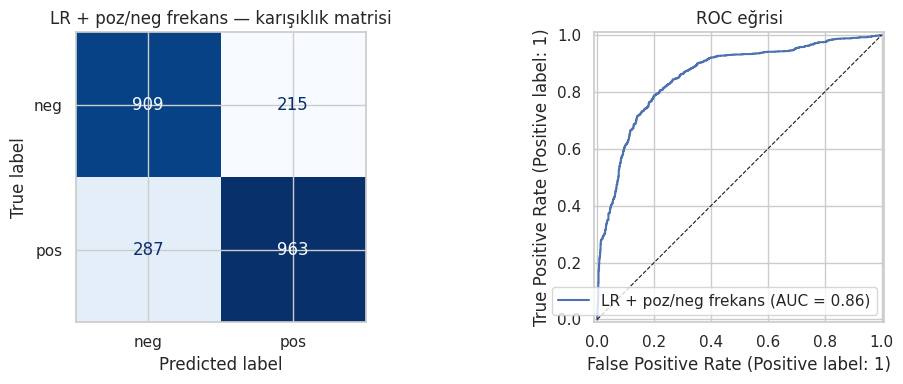

(0.7885425442291492, 0.7932454695222405, 0.8585441281138789)

In [21]:
from sklearn.linear_model import LogisticRegression

X_train_pn = np.vstack([tweet_to_freq(t, freqs) for t in X_train["tokens"]])
X_val_pn   = np.vstack([tweet_to_freq(t, freqs) for t in X_val["tokens"]])

lr_pn = LogisticRegression(max_iter=1000)
lr_pn.fit(X_train_pn, y_train)
evaluate("LR + poz/neg frekans", lr_pn, X_val_pn, y_val)

=== LR + BoW [val] ===
Accuracy: 0.9073 | F1: 0.9117 | ROC-AUC: 0.9631

              precision    recall  f1-score   support

    negative      0.899     0.906     0.902      1124
    positive      0.915     0.909     0.912      1250

    accuracy                          0.907      2374
   macro avg      0.907     0.907     0.907      2374
weighted avg      0.907     0.907     0.907      2374

=== LR + TF-IDF [val] ===
Accuracy: 0.9069 | F1: 0.9114 | ROC-AUC: 0.9678

              precision    recall  f1-score   support

    negative      0.899     0.905     0.902      1124
    positive      0.914     0.909     0.911      1250

    accuracy                          0.907      2374
   macro avg      0.907     0.907     0.907      2374
weighted avg      0.907     0.907     0.907      2374



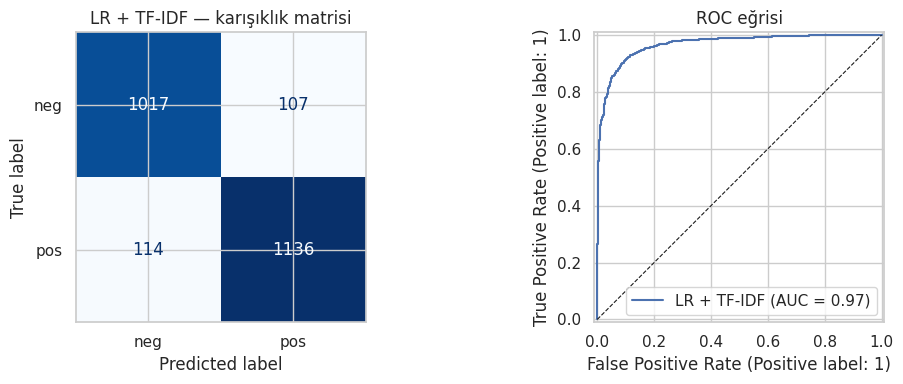

=== LinearSVC + TF-IDF [val] ===
Accuracy: 0.9048 | F1: 0.9095 | ROC-AUC: 0.9677

              precision    recall  f1-score   support

    negative      0.898     0.901     0.900      1124
    positive      0.911     0.908     0.909      1250

    accuracy                          0.905      2374
   macro avg      0.904     0.905     0.905      2374
weighted avg      0.905     0.905     0.905      2374

=== ComplementNB + TF-IDF [val] ===
Accuracy: 0.8842 | F1: 0.8874 | ROC-AUC: 0.9490

              precision    recall  f1-score   support

    negative      0.859     0.903     0.881      1124
    positive      0.909     0.867     0.887      1250

    accuracy                          0.884      2374
   macro avg      0.884     0.885     0.884      2374
weighted avg      0.885     0.884     0.884      2374



In [22]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV

models = {
    "LR + BoW": Pipeline([("vec", bow),
                          ("clf", LogisticRegression(max_iter=2000, C=1.0))]),
    "LR + TF-IDF": Pipeline([("vec", tfidf_union),
                             ("clf", LogisticRegression(max_iter=3000, C=4.0))]),
    "LinearSVC + TF-IDF": Pipeline([("vec", tfidf_union),
                                    ("clf", CalibratedClassifierCV(LinearSVC(C=0.5), cv=3))]),
    "ComplementNB + TF-IDF": Pipeline([("vec", tfidf_union),
                                       ("clf", ComplementNB(alpha=0.3))]),
}

fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train["tokens"], y_train)
    fitted[name] = pipe
    evaluate(name, pipe, X_val["tokens"], y_val, plot=(name == "LR + TF-IDF"))

In [23]:
from sklearn.decomposition import TruncatedSVD

try:
    from lightgbm import LGBMClassifier
    booster = LGBMClassifier(n_estimators=600, learning_rate=0.06, num_leaves=63,
                             subsample=0.9, colsample_bytree=0.7, random_state=SEED, verbose=-1)
    booster_name = "LightGBM + TF-IDF(SVD)"
except ImportError:
    from sklearn.ensemble import HistGradientBoostingClassifier
    booster = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08, random_state=SEED)
    booster_name = "HistGradientBoosting + TF-IDF(SVD)"
gb_pipe = Pipeline([
    ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True)),
    ("svd", TruncatedSVD(n_components=300, random_state=SEED)),
    ("clf", booster),
])
gb_pipe.fit(X_train["tokens"], y_train)
fitted[booster_name] = gb_pipe
evaluate(booster_name, gb_pipe, X_val["tokens"], y_val, plot=False)

=== LightGBM + TF-IDF(SVD) [val] ===
Accuracy: 0.8677 | F1: 0.8749 | ROC-AUC: 0.9423

              precision    recall  f1-score   support

    negative      0.864     0.856     0.860      1124
    positive      0.871     0.878     0.875      1250

    accuracy                          0.868      2374
   macro avg      0.867     0.867     0.867      2374
weighted avg      0.868     0.868     0.868      2374



(0.8677337826453243, 0.8749003984063745, 0.9423387900355873)

In [24]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

search_pipe = Pipeline([
    ("vec", TfidfVectorizer(sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=3000)),
])
param_dist = {
    "vec__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "vec__min_df": [1, 2, 3, 5],
    "vec__max_df": [0.7, 0.9, 1.0],
    "clf__C": loguniform(1e-2, 1e2),
    "clf__class_weight": [None, "balanced"],
}
search = RandomizedSearchCV(
    search_pipe, param_dist, n_iter=25, scoring="f1",
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=-1, verbose=1)
search.fit(X_train["tokens"], y_train)

print("En iyi CV F1:", round(search.best_score_, 4))
print("En iyi parametreler:", search.best_params_)
fitted["LR (ayarlanmış)"] = search.best_estimator_
evaluate("LR (ayarlanmış)", search.best_estimator_, X_val["tokens"], y_val, plot=False)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
En iyi CV F1: 0.8919
En iyi parametreler: {'clf__C': np.float64(21.51689729808333), 'clf__class_weight': None, 'vec__max_df': 0.9, 'vec__min_df': 1, 'vec__ngram_range': (1, 2)}
=== LR (ayarlanmış) [val] ===
Accuracy: 0.9014 | F1: 0.9065 | ROC-AUC: 0.9657

              precision    recall  f1-score   support

    negative      0.897     0.895     0.896      1124
    positive      0.906     0.907     0.906      1250

    accuracy                          0.901      2374
   macro avg      0.901     0.901     0.901      2374
weighted avg      0.901     0.901     0.901      2374



(0.9014321819713563, 0.9064748201438849, 0.9656725978647687)

In [25]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_ID = "cardiffnlp/twitter-roberta-base-sentiment-latest"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Cihaz:", device)

tok_pre = AutoTokenizer.from_pretrained(MODEL_ID)
mdl_pre = AutoModelForSequenceClassification.from_pretrained(MODEL_ID).to(device).eval()
print(mdl_pre.config.id2label)

Cihaz: cuda


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{0: 'negative', 1: 'neutral', 2: 'positive'}


In [26]:
@torch.no_grad()
def predict_pretrained(texts, batch_size=64, max_length=96):
    probs = []
    for i in range(0, len(texts), batch_size):
        batch = list(texts[i:i + batch_size])
        enc = tok_pre(batch, truncation=True, padding=True,
                      max_length=max_length, return_tensors="pt").to(device)
        logits = mdl_pre(**enc).logits
        probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.vstack(probs)

val_texts = X_val["clean"].tolist()
p = predict_pretrained(val_texts)

pos_score = p[:, 2] / (p[:, 0] + p[:, 2] + 1e-9)
pred_pre = (pos_score >= 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_val, pred_pre):.4f} | "
      f"F1: {f1_score(y_val, pred_pre):.4f} | ROC-AUC: {roc_auc_score(y_val, pos_score):.4f}")
RESULTS.append({"model": "RoBERTa (hazır, eğitimsiz)", "split": "val",
                "accuracy": accuracy_score(y_val, pred_pre),
                "f1": f1_score(y_val, pred_pre),
                "roc_auc": roc_auc_score(y_val, pos_score)})

Accuracy: 0.9212 | F1: 0.9258 | ROC-AUC: 0.9713


In [27]:
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          EarlyStoppingCallback)

BASE = "cardiffnlp/twitter-roberta-base-sentiment-latest"
MAX_LEN = 96

tokenizer = AutoTokenizer.from_pretrained(BASE)

def to_ds(X_part, y_part):
    ds = Dataset.from_dict({"text": X_part["clean"].tolist(), "labels": list(y_part)})
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN),
                  batched=True, remove_columns=["text"])

ds_train, ds_val, ds_test = to_ds(X_train, y_train), to_ds(X_val, y_val), to_ds(X_test, y_test)
print(ds_train)

Map:   0%|          | 0/13448 [00:00<?, ? examples/s]

Map:   0%|          | 0/2374 [00:00<?, ? examples/s]

Map:   0%|          | 0/2793 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 13448
})


In [28]:
import evaluate as hf_evaluate

acc_metric = hf_evaluate.load("accuracy")
f1_metric = hf_evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
            "f1": f1_metric.compute(predictions=preds, references=labels)["f1"]}

model = AutoModelForSequenceClassification.from_pretrained(
    BASE, num_labels=2, ignore_mismatched_sizes=True,
    id2label={0: "negative", 1: "positive"}, label2id={"negative": 0, "positive": 1})

import inspect
_ta_keys = inspect.signature(TrainingArguments.__init__).parameters
_eval_key = "eval_strategy" if "eval_strategy" in _ta_keys else "evaluation_strategy"

args = TrainingArguments(
    output_dir="./roberta-sentiment",
    **{_eval_key: "epoch"},
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.06,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    seed=SEED,
    report_to="none",
)
common = dict(model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
              data_collator=DataCollatorWithPadding(tokenizer),
              compute_metrics=compute_metrics,
              callbacks=[EarlyStoppingCallback(early_stopping_patience=1)])
try:
    trainer = Trainer(processing_class=tokenizer, **common)
except TypeError:
    trainer = Trainer(tokenizer=tokenizer, **common)
trainer.train()

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |                                                                                       
----------------------------+------------+---------------------------------------------------------------------------------------
roberta.pooler.dense.bias   | UNEXPECTED |                                                                                       
roberta.pooler.dense.weight | UNEXPECTED |                                                                                       
classifier.out_proj.bias    | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.out_proj.weight  | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect 

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.174929,0.153148,0.953665,0.956556
2,0.108672,0.139076,0.950295,0.952496


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=842, training_loss=0.1653647558706107, metrics={'train_runtime': 120.9355, 'train_samples_per_second': 333.599, 'train_steps_per_second': 10.444, 'total_flos': 547464217330080.0, 'train_loss': 0.1653647558706107, 'epoch': 2.0})

In [29]:
val_out = trainer.predict(ds_val)
val_probs = torch.softmax(torch.tensor(val_out.predictions), dim=-1).numpy()[:, 1]
val_preds = val_probs.argmax if False else (val_probs >= 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f} | "
      f"F1: {f1_score(y_val, val_preds):.4f} | ROC-AUC: {roc_auc_score(y_val, val_probs):.4f}")
print(classification_report(y_val, val_preds, target_names=["negative", "positive"], digits=3))

RESULTS.append({"model": "RoBERTa (fine-tuned)", "split": "val",
                "accuracy": accuracy_score(y_val, val_preds),
                "f1": f1_score(y_val, val_preds),
                "roc_auc": roc_auc_score(y_val, val_probs)})

Accuracy: 0.9537 | F1: 0.9566 | ROC-AUC: 0.9878
              precision    recall  f1-score   support

    negative      0.964     0.937     0.950      1124
    positive      0.945     0.969     0.957      1250

    accuracy                          0.954      2374
   macro avg      0.954     0.953     0.953      2374
weighted avg      0.954     0.954     0.954      2374



,model,split,accuracy,f1,roc_auc
0,RoBERTa (fine-tuned),val,0.9537,0.9566,0.9878
1,"RoBERTa (hazır, eğitimsiz)",val,0.9212,0.9258,0.9713
2,LR + BoW,val,0.9073,0.9117,0.9631
3,LR + TF-IDF,val,0.9069,0.9114,0.9678
4,LinearSVC + TF-IDF,val,0.9048,0.9095,0.9677
5,LR (ayarlanmış),val,0.9014,0.9065,0.9657
6,ComplementNB + TF-IDF,val,0.8842,0.8874,0.9490
7,LightGBM + TF-IDF(SVD),val,0.8677,0.8749,0.9423
8,LR + poz/neg frekans,val,0.7885,0.7932,0.8585


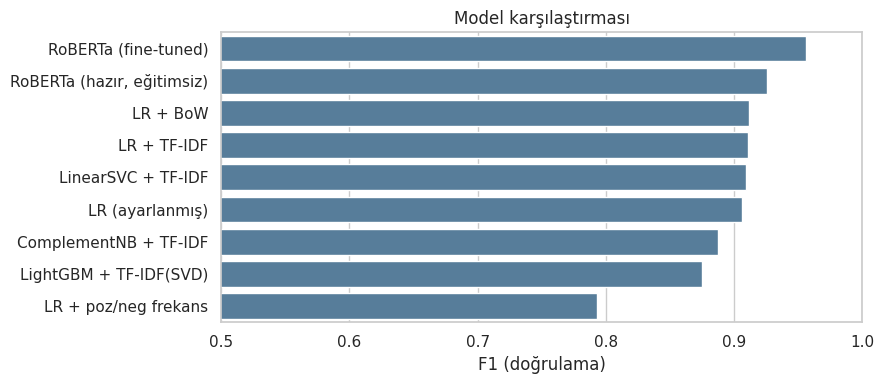

In [30]:
res = pd.DataFrame(RESULTS).sort_values("f1", ascending=False).reset_index(drop=True)
display(res.style.format({"accuracy": "{:.4f}", "f1": "{:.4f}", "roc_auc": "{:.4f}"})
           .background_gradient(subset=["f1"], cmap="Greens"))

plt.figure(figsize=(9, 4))
sns.barplot(data=res, y="model", x="f1", color="#4C7FA5")
plt.xlim(0.5, 1.0); plt.xlabel("F1 (doğrulama)"); plt.ylabel("")
plt.title("Model karşılaştırması"); plt.tight_layout(); plt.show()

En iyi klasik model: LR + BoW
=== LR + BoW [test] ===
Accuracy: 0.8876 | F1: 0.8922 | ROC-AUC: 0.9568

              precision    recall  f1-score   support

    negative      0.873     0.892     0.883      1323
    positive      0.901     0.884     0.892      1470

    accuracy                          0.888      2793
   macro avg      0.887     0.888     0.887      2793
weighted avg      0.888     0.888     0.888      2793



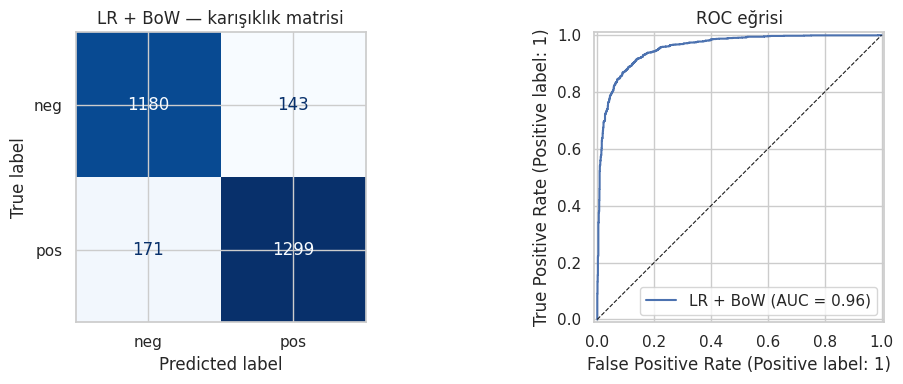

(0.8875760830648048, 0.8921703296703297, 0.956752073467331)

In [31]:
best_classic_name = max(
    (r for r in RESULTS if r["model"] in fitted), key=lambda r: r["f1"])["model"]
print("En iyi klasik model:", best_classic_name)
best_classic = fitted[best_classic_name]
evaluate(best_classic_name, best_classic, X_test["tokens"], y_test, split="test")

In [32]:
try:
    test_out = trainer.predict(ds_test)
    test_probs = torch.softmax(torch.tensor(test_out.predictions), dim=-1).numpy()[:, 1]
    test_preds = (test_probs >= 0.5).astype(int)
    print(f"RoBERTa (fine-tuned) [test] Accuracy: {accuracy_score(y_test, test_preds):.4f} | "
          f"F1: {f1_score(y_test, test_preds):.4f} | ROC-AUC: {roc_auc_score(y_test, test_probs):.4f}")
    print(classification_report(y_test, test_preds, target_names=["negative", "positive"], digits=3))
except NameError:
    print("Transformer bölümü çalıştırılmadı, atlanıyor.")

RoBERTa (fine-tuned) [test] Accuracy: 0.9467 | F1: 0.9498 | ROC-AUC: 0.9841
              precision    recall  f1-score   support

    negative      0.954     0.933     0.943      1323
    positive      0.941     0.959     0.950      1470

    accuracy                          0.947      2793
   macro avg      0.947     0.946     0.946      2793
weighted avg      0.947     0.947     0.947      2793



In [33]:
proba_classic = best_classic.predict_proba(X_test["tokens"])[:, 1] \
    if hasattr(best_classic, "predict_proba") else best_classic.decision_function(X_test["tokens"])
pred_classic = (proba_classic >= 0.5).astype(int)

err = pd.DataFrame({
    "text": df.loc[X_test.index, "tweet_text"].values,
    "true": y_test.values,
    "pred": pred_classic,
    "p_pos": proba_classic,
})
err["confidence"] = np.abs(err["p_pos"] - 0.5)
wrong = err[err["true"] != err["pred"]].sort_values("confidence", ascending=False)

print(f"Toplam hata: {len(wrong)} / {len(err)}  ({len(wrong)/len(err):.2%})")
wrong.head(15)[["text", "true", "pred", "p_pos"]]

Toplam hata: 314 / 2793  (11.24%)


,text,true,pred,p_pos
2177,i ditched school ( i hate it ) and im taking a huge dump....... it hurts REAL BAD!,1,0,0.000123
1752,@DawnRichard have an amazing time with your mommas tomorrow! Show them how much they mean to you Whatever you do th...,0,1,0.998750
14,@TokiWartooth Thanks! My mom's seed is larger and already cracked (and planted). I hope Avalina isn't a dud!,0,1,0.996632
1357,@bubzbeauty awww. i wish i had a younger sis ): but i do have an older one!!! i bet your younger sis loves it JUST a...,0,1,0.995129
740,Happy Mother's Day to every mommy out there,0,1,0.990685
2645,happy mothers day to all you mums out there,0,1,0.990453
1797,@jenrolton awwwww would a virtual high five make it any better?,0,1,0.976534
1889,"You know when your make late night calls to India team members for more pictures, your struggling with your message....",0,1,0.976256
2149,Redskins release Jon Jansen. That guy put in a ton of sweat and bruises for the team. He will be missed. http:/...,1,0,0.025693
2466,Zach G. gets an extensive profile in this weekend's NY Times Magazine. The chances of us falling in love are getting...,0,1,0.970792


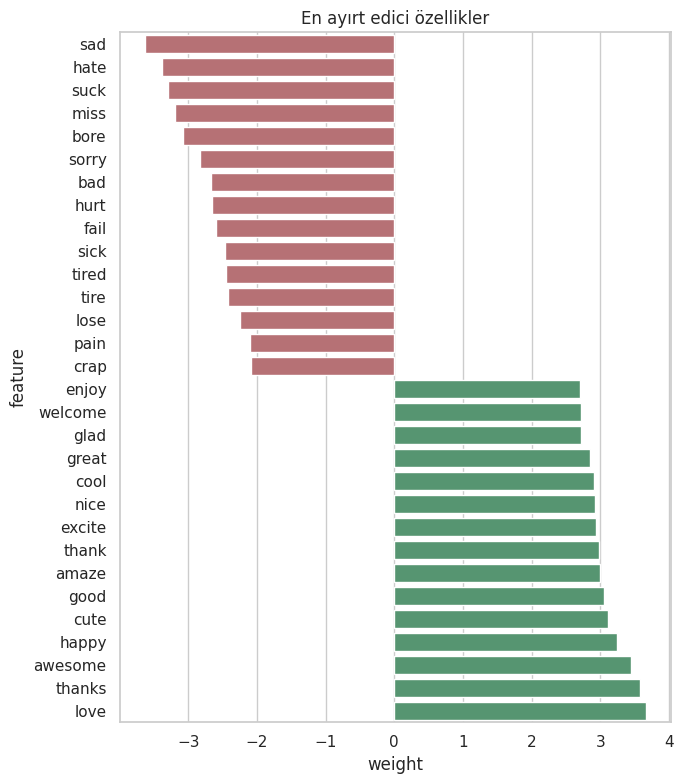

In [34]:
try:
    vec = best_classic.named_steps["vec"]
    clf = best_classic.named_steps["clf"]
    coefs = clf.coef_[0]
    names = np.array(vec.get_feature_names_out())
    order = np.argsort(coefs)
    top = pd.DataFrame({"feature": np.r_[names[order[:15]], names[order[-15:]]],
                        "weight":  np.r_[coefs[order[:15]], coefs[order[-15:]]]})
    plt.figure(figsize=(7, 8))
    sns.barplot(data=top, y="feature", x="weight",
                palette=["#C1666B"]*15 + ["#4C9F70"]*15)
    plt.title("En ayırt edici özellikler"); plt.tight_layout(); plt.show()
except (AttributeError, KeyError) as e:
    print("Bu model için doğrudan katsayı çıkarılamıyor:", e)

In [35]:
import joblib

joblib.dump(best_classic, "sentiment_classic.joblib")
print("Klasik model kaydedildi -> sentiment_classic.joblib")

try:
    trainer.save_model("./roberta-sentiment-best")
    tokenizer.save_pretrained("./roberta-sentiment-best")
    print("Transformer kaydedildi -> ./roberta-sentiment-best")
except NameError:
    pass

Klasik model kaydedildi -> sentiment_classic.joblib


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Transformer kaydedildi -> ./roberta-sentiment-best


In [36]:
def predict_sentiment(text, model="classic"):
    """Tek bir tweet için duygu tahmini döndürür."""
    if model == "classic":
        pipe = joblib.load("sentiment_classic.joblib")
        feats = [process_tweet(text)]
        prob = pipe.predict_proba(feats)[0, 1] if hasattr(pipe, "predict_proba") \
            else float(pipe.decision_function(feats)[0] > 0)
    else:
        from transformers import pipeline
        hf = pipeline("sentiment-analysis", model="./roberta-sentiment-best",
                      device=0 if torch.cuda.is_available() else -1)
        out = hf(clean_text(text))[0]
        prob = out["score"] if out["label"] == "positive" else 1 - out["score"]
    label = "positive" if prob >= 0.5 else "negative"
    return {"text": text, "sentiment": label, "p_positive": round(float(prob), 4)}


for t in ["I absolutely love this, best day ever!",
          "this is not good at all",
          "meh, could have been worse I guess",
          "RT @someone: worst customer service I've ever had 😡 https://t.co/x"]:
    print(predict_sentiment(t))

{'text': 'I absolutely love this, best day ever!', 'sentiment': 'positive', 'p_positive': 0.9986}
{'text': 'this is not good at all', 'sentiment': 'negative', 'p_positive': 0.059}
{'text': 'meh, could have been worse I guess', 'sentiment': 'negative', 'p_positive': 0.2169}
{'text': "RT @someone: worst customer service I've ever had 😡 https://t.co/x", 'sentiment': 'negative', 'p_positive': 0.2749}
